# Phase-resolved OpenDSS results

This notebook reads the tables written by `uv run maez-run`. It displays phase and net load, PV, source, voltage, current, and power-balance results without rerunning OpenDSS.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "results").is_dir() else cwd.parent
results_dir = project_root / "results"

def load_table(stem: str) -> pd.DataFrame:
    """Prefer typed Parquet results and fall back to CSV."""
    parquet = results_dir / f"{stem}.parquet"
    csv = results_dir / f"{stem}.csv"
    if parquet.is_file():
        table = pd.read_parquet(parquet)
    elif csv.is_file():
        table = pd.read_csv(csv)
    else:
        raise FileNotFoundError(f"Missing result table: {stem}. Run 'uv run maez-run'.")
    table["Datetime"] = pd.to_datetime(table["Datetime"])
    return table

elements = load_table("element_timeseries")
bus_voltages = load_table("bus_voltage_timeseries")
utility = load_table("utility_line_timeseries")
system = load_table("system_timeseries")
inputs = load_table("applied_inputs")

print(f"Time steps: {system['Datetime'].nunique():,}")
print(f"Range: {system['Datetime'].min()} to {system['Datetime'].max()}")

Time steps: 2
Range: 2026-07-01 12:00:00 to 2026-07-01 12:30:00


## Applied inputs

In [2]:
display(inputs.query("InputType == 'Load'").head(9))
display(inputs.query("InputType == 'PVSystem'").head())

,Datetime,InputType,Element,Phase,P_kW,Q_kvar,Irradiance_kW_m2,Temperature_C,Pmpp_kW,kVA,PF
0,2026-07-01 12:00:00,Load,load_8A,A,18.0,6.0,NaN,NaN,NaN,NaN,NaN
1,2026-07-01 12:00:00,Load,load_8B,B,15.0,5.0,NaN,NaN,NaN,NaN,NaN
2,2026-07-01 12:00:00,Load,load_8C,C,12.0,4.0,NaN,NaN,NaN,NaN,NaN
3,2026-07-01 12:00:00,Load,load_9A,A,9.0,3.0,NaN,NaN,NaN,NaN,NaN
4,2026-07-01 12:00:00,Load,load_9B,B,8.0,2.5,NaN,NaN,NaN,NaN,NaN
5,2026-07-01 12:00:00,Load,load_9C,C,7.0,2.0,NaN,NaN,NaN,NaN,NaN
6,2026-07-01 12:00:00,Load,load_11A,A,15.0,5.0,NaN,NaN,NaN,NaN,NaN
7,2026-07-01 12:00:00,Load,load_11B,B,13.0,4.0,NaN,NaN,NaN,NaN,NaN
8,2026-07-01 12:00:00,Load,load_11C,C,11.0,3.0,NaN,NaN,NaN,NaN,NaN


,Datetime,InputType,Element,Phase,P_kW,Q_kvar,Irradiance_kW_m2,Temperature_C,Pmpp_kW,kVA,PF
21,2026-07-01 12:00:00,PVSystem,PV_346kW,NET,NaN,NaN,0.5,30.0,346.0,346.0,1.0
43,2026-07-01 12:30:00,PVSystem,PV_346kW,NET,NaN,NaN,0.8,35.0,346.0,346.0,1.0


## System power balance

Source import is positive. PV generation is reported as a positive generated quantity. Losses satisfy `Source = Gross load - PV generation + Loss`.

In [3]:
system.sort_values(["Datetime", "Phase"]).head(8)

,Datetime,Phase,GrossLoadP_kW,GrossLoadQ_kvar,PVGenerationP_kW,PVGenerationQ_kvar,SourceP_kW,SourceQ_kvar,LossP_kW,LossQ_kvar
0,2026-07-01 12:00:00,A,92.000000,30.500000,57.666667,4.071557e-08,34.380837,23.253494,0.047504,-7.246506
1,2026-07-01 12:00:00,B,79.000000,25.000000,57.666667,-1.939751e-08,21.360574,17.746969,0.027240,-7.253031
2,2026-07-01 12:00:00,C,66.000000,19.500000,57.666667,2.980752e-08,8.353949,12.237433,0.020616,-7.262567
3,2026-07-01 12:00:00,NET,237.000000,75.000000,173.000000,5.112557e-08,64.095360,53.237895,0.095360,-21.762105
4,2026-07-01 12:30:00,A,100.999993,32.499958,92.266604,-6.267138e-05,8.803519,25.269777,0.070129,-7.230244
5,2026-07-01 12:30:00,B,86.999992,26.699974,92.266616,-5.056214e-05,-5.214391,19.459763,0.052233,-7.240262
6,2026-07-01 12:30:00,C,73.499988,21.199972,92.266612,-5.769451e-05,-18.712967,13.962544,0.053657,-7.237485
7,2026-07-01 12:30:00,NET,261.499973,80.399904,276.799832,-1.709280e-04,-15.123839,58.692084,0.176019,-21.707991


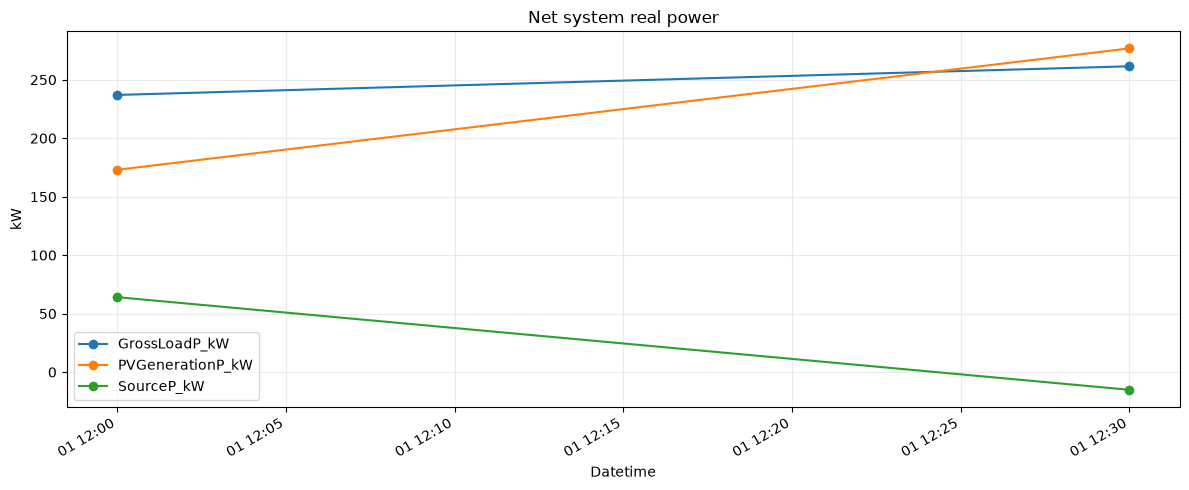

In [4]:
net_system = system.query("Phase == 'NET'").set_index("Datetime")
ax = net_system[["GrossLoadP_kW", "PVGenerationP_kW", "SourceP_kW"]].plot(
    figsize=(12, 5), marker="o"
)
ax.set_title("Net system real power")
ax.set_ylabel("kW")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

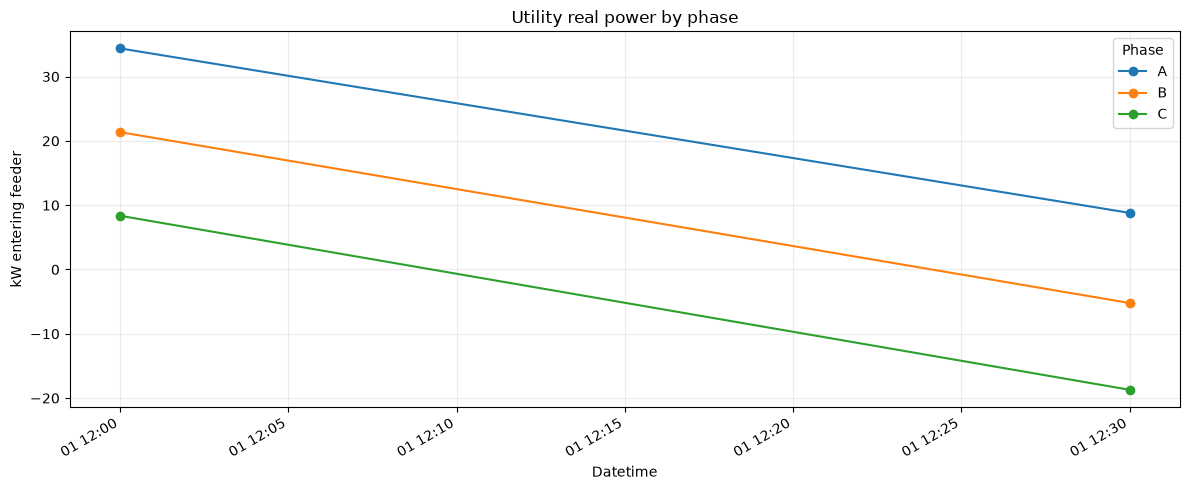

In [5]:
phase_source = system.query("Phase != 'NET'").pivot(
    index="Datetime", columns="Phase", values="SourceP_kW"
)
ax = phase_source.plot(figsize=(12, 5), marker="o")
ax.set_title("Utility real power by phase")
ax.set_ylabel("kW entering feeder")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Utility-line terminal measurements

In [6]:
utility.query("Phase != 'NET'")[[
    "Datetime", "Phase", "P_kW", "Q_kvar", "I_A", "V_V"
]].head(9)

,Datetime,Phase,P_kW,Q_kvar,I_A,V_V
0,2026-07-01 12:00:00,A,34.380837,23.253494,5.765134,7199.525426
1,2026-07-01 12:00:00,B,21.360574,17.746969,3.857335,7199.532309
2,2026-07-01 12:00:00,C,8.353949,12.237433,2.058046,7199.543270
4,2026-07-01 12:30:00,A,8.803519,25.269777,3.716821,7199.530040
5,2026-07-01 12:30:00,B,-5.214391,19.459763,2.798273,7199.537394
6,2026-07-01 12:30:00,C,-18.712967,13.962544,3.242977,7199.548606


## Bus voltage profile

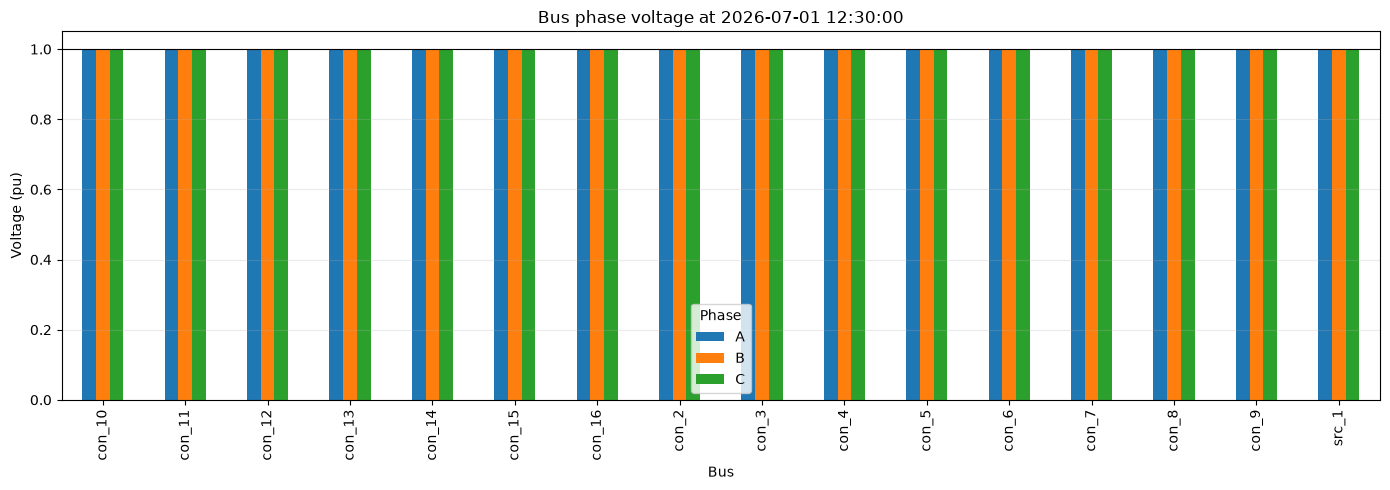

In [7]:
selected_time = bus_voltages["Datetime"].iloc[-1]
voltage_snapshot = bus_voltages.query("Datetime == @selected_time")
voltage_pivot = voltage_snapshot.pivot(index="Bus", columns="Phase", values="V_pu")
ax = voltage_pivot.plot.bar(figsize=(14, 5))
ax.axhline(1.0, color="black", linewidth=0.8)
ax.set_title(f"Bus phase voltage at {selected_time}")
ax.set_ylabel("Voltage (pu)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Load and PV terminal measurements

In [8]:
selected_elements = ["load_8A", "load_8B", "load_8C", "PV_346kW"]
elements.query("Element in @selected_elements and Phase != 'NET'")[[
    "Datetime", "ElementClass", "Element", "Phase",
    "P_kW", "Q_kvar", "I_A", "V_V"
]].head(12)

,Datetime,ElementClass,Element,Phase,P_kW,Q_kvar,I_A,V_V
0,2026-07-01 12:00:00,Load,load_8A,A,18.000000,6.000000e+00,2.636777,7195.778339
1,2026-07-01 12:00:00,Load,load_8B,B,15.000000,5.000000e+00,2.196875,7197.217684
2,2026-07-01 12:00:00,Load,load_8C,C,12.000000,4.000000e+00,1.757092,7198.889378
21,2026-07-01 12:00:00,PVSystem,PV_346kW,A,-57.666667,-4.071557e-08,8.011072,7198.371035
22,2026-07-01 12:00:00,PVSystem,PV_346kW,B,-57.666667,1.939751e-08,8.009610,7199.684568
23,2026-07-01 12:00:00,PVSystem,PV_346kW,C,-57.666667,-2.980752e-08,8.007581,7201.508818
46,2026-07-01 12:30:00,Load,load_8A,A,19.999999,6.499994e+00,2.922168,7196.621038
47,2026-07-01 12:30:00,Load,load_8B,B,15.999999,5.199997e+00,2.337246,7198.126285
48,2026-07-01 12:30:00,Load,load_8C,C,12.999999,4.199997e+00,1.897498,7199.808786
67,2026-07-01 12:30:00,PVSystem,PV_346kW,A,-92.266604,6.267138e-05,12.812411,7201.345946


## Numerical balance validation

In [9]:
balance_error_kw = (
    system["SourceP_kW"]
    - system["GrossLoadP_kW"]
    + system["PVGenerationP_kW"]
    - system["LossP_kW"]
)
pd.Series({
    "maximum absolute P balance error (kW)": balance_error_kw.abs().max(),
    "minimum bus voltage (pu)": bus_voltages["V_pu"].min(),
    "maximum bus voltage (pu)": bus_voltages["V_pu"].max(),
})

maximum absolute P balance error (kW)    0.000000
minimum bus voltage (pu)                 0.999212
maximum bus voltage (pu)                 1.000638
dtype: float64